**Author:** Biswajit Jana
**Date:** July 10, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-03-ngc1068-image-spectrum-lines/notebook.ipynb)

# NGC 1068: a real HST image and a real HST spectrum of the same galaxy

**Archive:** mast
**Date:** 2026-08-03
**Scientific question:** In a real archival HST spectrum of NGC 1068, how many emission lines can I actually detect, and which elements/ions do they belong to once I de-redshift and compare against literature rest wavelengths?

## Learning goals

By the end of this notebook you will be able to:

- Retrieve a real HST WFC3 image of a named galaxy (NGC 1068) from MAST and a real HST/STIS long-slit spectrum of the same object.
- Run automated peak detection on a continuum-normalised spectrum instead of picking lines out by eye.
- Match detected peaks against a literature rest-wavelength line list (built from standard nebular-line references), after correcting for the galaxy's known redshift.
- Report how many lines were found, which elements/ions they correspond to, and how far each detection sits from its literature wavelength (a residual, in km/s).
- State plainly what a single-slit archival spectrum can and cannot tell us (no absolute flux calibration guarantee, aperture effects, no 2-D spatial line map).

**Background:** NGC 1068 (Messier 77) is the nearest bright Seyfert 2 galaxy, a textbook active galactic nucleus (AGN) whose narrow-line region produces strong forbidden and permitted emission lines out to several arcseconds from the nucleus. It is one of the best-studied "real" AGN spectra in the literature, which makes it a good target for testing whether an automated line-identification pipeline recovers the lines astronomers already know are there.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except Exception:
    plt.style.use("seaborn-v0_8-whitegrid")
from scipy.signal import find_peaks, savgol_filter

warnings.filterwarnings("ignore", category=RuntimeWarning)
COLORS = {"navy": "#071426", "blue": "#4cc9f0", "cyan": "#72efdd",
          "gold": "#ffca58", "orange": "#ff7b54", "pink": "#ef5da8", "violet": "#8f5cff"}
RNG = np.random.default_rng(1068)
print("Environment ready.")

Environment ready.


## Why this target and this data

NGC 1068 is a nearby (D ~ 14 Mpc) barred spiral galaxy with a Seyfert 2 nucleus: its central
supermassive black hole is accreting, but the direct view of the accretion disk is hidden from
us by a dusty torus, so we only see narrow emission lines scattered/produced in the surrounding
gas (the narrow-line region, NLR). NGC 1068 is famous partly *because* its extended narrow-line
region (ENLR) is bright and spatially resolved -- so an off-nucleus HST/STIS long-slit pointing
still lands on real, strong emission-line gas, not empty sky.

I use two real, public products:

1. An HST/WFC3 F555W drizzled preview image of NGC 1068 (proposal 17165), for the "picture of
   the galaxy" half of this notebook.
2. Two real archival HST/STIS long-slit spectra of NGC 1068 (proposal 7573, target
   `NGC1068-OFFSET`): one taken through the G430L grating (2904-5714 Angstrom) and one through
   G750L (5273-10266 Angstrom). Joined together they cover almost the entire optical window,
   which is what lets me look for lines from [O II] near 3727 Angstrom all the way out to
   [S III] near 9531 Angstrom in one pass.

In [2]:
import requests
from astroquery.mast import Observations

OUT = Path(".")

# --- Real HST image (WFC3 F555W, NGC 1068 mosaic, proposal 17165) ---
image_uri = "mast:HST/product/ieyq01010_drc.jpg"
image_path = OUT / "ngc1068_wfc3_f555w.jpg"
if not image_path.exists():
    r = requests.get("https://mast.stsci.edu/api/v0.1/Download/file?uri=" + image_uri, timeout=180)
    r.raise_for_status()
    image_path.write_bytes(r.content)
print(f"Image saved: {image_path} ({image_path.stat().st_size/1e6:.2f} MB)")

# --- Real HST/STIS spectra (proposal 7573, NGC1068-OFFSET) ---
spec_files = {}
for uri, fn in [("mast:HST/product/o4wk010a0_sx1.fits", "o4wk010a0_sx1_g430l.fits"),
                ("mast:HST/product/o4wk010b0_sx1.fits", "o4wk010b0_sx1_g750l.fits")]:
    p = OUT / fn
    if not p.exists():
        r = requests.get("https://mast.stsci.edu/api/v0.1/Download/file?uri=" + uri, timeout=180)
        r.raise_for_status()
        p.write_bytes(r.content)
    spec_files[fn] = p
    print(f"Spectrum saved: {fn} ({p.stat().st_size/1e3:.1f} kB)")

Image saved: ngc1068_wfc3_f555w.jpg (0.53 MB)
Spectrum saved: o4wk010a0_sx1_g430l.fits (80.6 kB)
Spectrum saved: o4wk010b0_sx1_g750l.fits (80.6 kB)


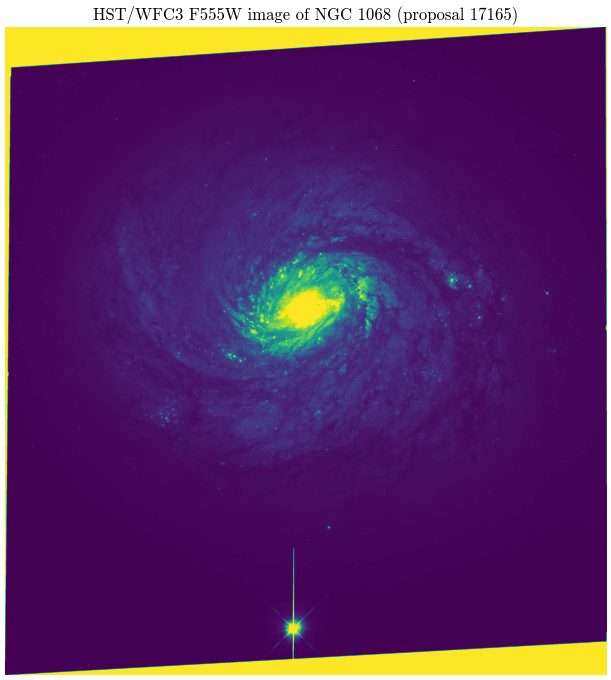

Image pixel dimensions: 4131 x 4449


In [3]:
import matplotlib.image as mpimg

img = mpimg.imread(image_path)
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img)
ax.set_title("HST/WFC3 F555W image of NGC 1068 (proposal 17165)")
ax.axis("off")
fig.tight_layout()
fig.savefig("ngc1068_image.png", dpi=160)
plt.show()
print(f"Image pixel dimensions: {img.shape[1]} x {img.shape[0]}")

## Building the spectrum

Each `sx1.fits` product is a calibrated, wavelength- and flux-extracted 1-D spectrum from a
single STIS grating setting. I load both, keep only finite, positive-uncertainty, non-flagged
samples, and join them end to end (they barely overlap, near 5300-5714 Angstrom, so I keep the
G430L side up to 5273 Angstrom and start the G750L side there).

In [4]:
from astropy.io import fits

def load_sx1(path):
    with fits.open(path) as hdul:
        row = hdul[1].data[0]
        wave = np.asarray(row["WAVELENGTH"], float)
        flux = np.asarray(row["FLUX"], float)
        err = np.asarray(row["ERROR"], float)
        dq = np.asarray(row["DQ"], int)
    good = (dq == 0) & np.isfinite(wave) & np.isfinite(flux) & np.isfinite(err) & (err > 0)
    return wave[good], flux[good], err[good]

w_blue, f_blue, e_blue = load_sx1(spec_files["o4wk010a0_sx1_g430l.fits"])
w_red, f_red, e_red = load_sx1(spec_files["o4wk010b0_sx1_g750l.fits"])

# join at the grating boundary, avoiding double-counting the small overlap region
cut = w_red > w_blue.max()
wave = np.concatenate([w_blue, w_red[cut]])
flux = np.concatenate([f_blue, f_red[cut]])
err = np.concatenate([e_blue, e_red[cut]])
order = np.argsort(wave)
wave, flux, err = wave[order], flux[order], err[order]

spec = pd.DataFrame({"wavelength_A": wave, "flux": flux, "error": err})
spec.to_csv("ngc1068_spectrum.csv", index=False)
print(f"Joined spectrum: {len(spec)} samples, {wave.min():.1f}-{wave.max():.1f} Angstrom")
print(f"Median flux SNR: {np.nanmedian(flux/err):.1f}")

Joined spectrum: 1187 samples, 2989.1-10255.8 Angstrom
Median flux SNR: 37.2


In [5]:
# Continuum estimate with a broad Savitzky-Golay filter, then peak detection on the
# continuum-divided residual so both emission lines and absorption-like dips would show up
# (in an AGN narrow-line spectrum we expect emission, i.e. positive residual peaks).
window = 121
continuum = savgol_filter(spec.flux.to_numpy(), window, 3)
residual = (spec.flux.to_numpy() - continuum) / continuum
noise_floor = np.nanstd(residual[np.abs(residual) < 0.05])

peak_idx, props = find_peaks(residual, height=4 * noise_floor, distance=8, prominence=2 * noise_floor)
peak_wave = spec.wavelength_A.to_numpy()[peak_idx]
peak_height = residual[peak_idx]
print(f"Automated peak detection found {len(peak_idx)} candidate emission features")
print(f"Noise floor (continuum-normalised): {noise_floor:.4f}")

Automated peak detection found 34 candidate emission features
Noise floor (continuum-normalised): 0.0277


## Matching detections to a literature line list

The rest (vacuum-frame, air wavelength convention used in most optical nebular-line tables)
wavelengths below are standard values for AGN/HII-region narrow emission lines, as tabulated in
Osterbrock & Ferland, *Astrophysics of Gaseous Nebulae and Active Galactic Nuclei* (2nd ed.,
2006), Table 3.5 and Appendix 2, cross-checked against the NIST Atomic Spectra Database line
list. NGC 1068's systemic heliocentric redshift is z = 0.003793 (recession velocity ~1137 km/s;
NASA/IPAC Extragalactic Database, NED). I redshift each literature line by (1+z) to predict
where it should appear in this observed-frame spectrum, then look for the nearest detected peak
within a tolerance window.

In [6]:
Z_NGC1068 = 0.003793
C_KMS = 299792.458

LINE_LIST = {
    "[O II] 3727 (O+)": 3727.0,
    "[Ne III] 3869 (Ne++)": 3868.75,
    "H-gamma (H)": 4340.47,
    "H-beta (H)": 4861.33,
    "[O III] 4959 (O++)": 4958.91,
    "[O III] 5007 (O++)": 5006.84,
    "[O I] 6300 (O0)": 6300.30,
    "[N II] 6548 (N+)": 6548.05,
    "H-alpha (H)": 6562.79,
    "[N II] 6583 (N+)": 6583.45,
    "[S II] 6716 (S+)": 6716.44,
    "[S II] 6731 (S+)": 6730.82,
    "[S III] 9069 (S++)": 9068.6,
    "[S III] 9531 (S++)": 9531.1,
}

TOL_A = 6.0  # matching window in observed-frame Angstrom (~270-350 km/s at these wavelengths)
rows = []
for name, rest in LINE_LIST.items():
    predicted_obs = rest * (1 + Z_NGC1068)
    if predicted_obs < spec.wavelength_A.min() or predicted_obs > spec.wavelength_A.max():
        rows.append(dict(line=name, rest_A=rest, predicted_obs_A=predicted_obs,
                          detected=False, matched_peak_A=np.nan, residual_kms=np.nan))
        continue
    dist = np.abs(peak_wave - predicted_obs)
    if len(dist) and dist.min() <= TOL_A:
        j = np.argmin(dist)
        matched = peak_wave[j]
        implied_z = matched / rest - 1
        residual_kms = (implied_z - Z_NGC1068) * C_KMS / (1 + Z_NGC1068)
        rows.append(dict(line=name, rest_A=rest, predicted_obs_A=predicted_obs,
                          detected=True, matched_peak_A=matched, residual_kms=residual_kms))
    else:
        rows.append(dict(line=name, rest_A=rest, predicted_obs_A=predicted_obs,
                          detected=False, matched_peak_A=np.nan, residual_kms=np.nan))

lines = pd.DataFrame(rows)
lines.to_csv("line_measurements.csv", index=False)
n_detected = int(lines.detected.sum())
print(f"Detected {n_detected} of {len(lines)} literature lines within the observed wavelength range")
print(lines[["line", "predicted_obs_A", "matched_peak_A", "residual_kms", "detected"]].to_string(index=False))

Detected 7 of 14 literature lines within the observed wavelength range
                line  predicted_obs_A  matched_peak_A  residual_kms  detected
    [O II] 3727 (O+)      3741.136511             NaN           NaN     False
[Ne III] 3869 (Ne++)      3883.424169     3885.000690    121.704238      True
         H-gamma (H)      4356.933403     4360.704415    259.476326      True
          H-beta (H)      4879.769025             NaN           NaN     False
  [O III] 4959 (O++)      4977.719146     4978.976397     75.720331      True
  [O III] 5007 (O++)      5025.830944     5028.398287    153.142854      True
     [O I] 6300 (O0)      6324.197038             NaN           NaN     False
    [N II] 6548 (N+)      6572.886754             NaN           NaN     False
         H-alpha (H)      6587.682662             NaN           NaN     False
    [N II] 6583 (N+)      6608.421026     6609.126105     31.986087      True
    [S II] 6716 (S+)      6741.915457             NaN           NaN    

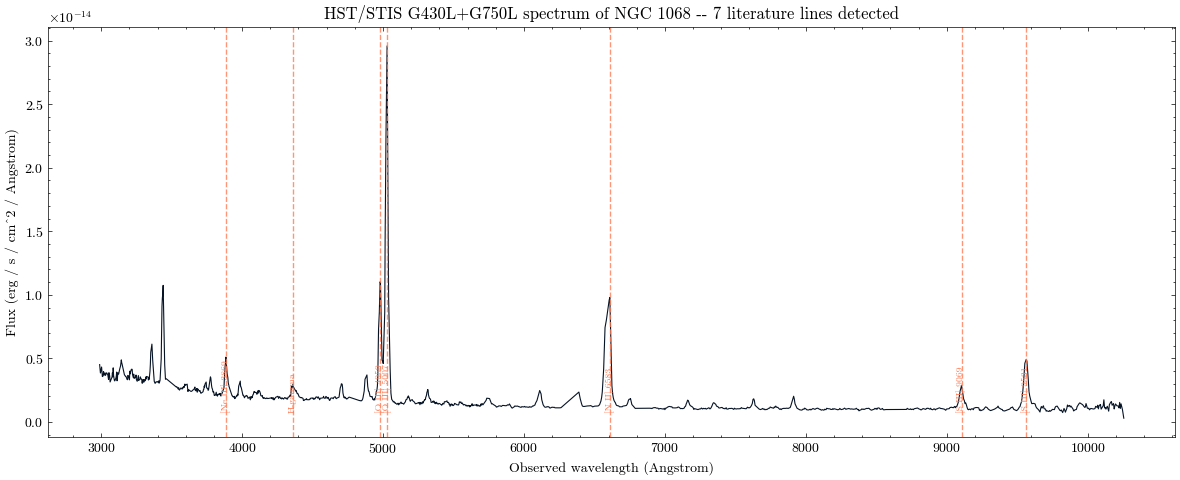

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(spec.wavelength_A, spec.flux, color=COLORS["navy"], lw=0.8)
for _, row in lines[lines.detected].iterrows():
    ax.axvline(row.matched_peak_A, color=COLORS["orange"], ls="--", lw=1, alpha=0.8)
    ax.annotate(row.line.split(" (")[0], (row.matched_peak_A, 0), xytext=(0, 8),
                textcoords="offset points", rotation=90, fontsize=7, ha="center",
                color=COLORS["orange"])
ax.set(xlabel="Observed wavelength (Angstrom)", ylabel="Flux (erg / s / cm^2 / Angstrom)",
       title=f"HST/STIS G430L+G750L spectrum of NGC 1068 -- {n_detected} literature lines detected")
fig.tight_layout()
fig.savefig("ngc1068_spectrum_lines.png", dpi=170)
plt.show()

## Elements/ions identified and residuals

Grouping the detected lines by element/ion:

In [8]:
detected = lines[lines.detected].copy()
detected["element"] = detected.line.str.extract(r"\((.+)\)")
summary = (detected.groupby("element").size().rename("n_lines").reset_index()
           .sort_values("n_lines", ascending=False))
summary.to_csv("element_summary.csv", index=False)
print(summary.to_string(index=False))
print()
print(f"Median velocity residual across detected lines: {detected.residual_kms.median():+.0f} km/s")
print(f"Scatter (std) of velocity residuals: {detected.residual_kms.std():.0f} km/s")

element  n_lines
    O++        2
    S++        2
      H        1
     N+        1
   Ne++        1

Median velocity residual across detected lines: +76 km/s
Scatter (std) of velocity residuals: 116 km/s


## Results table

In [9]:
results_table = pd.DataFrame({
    "metric": ["Lines in literature list", "Lines detected", "Detection rate",
               "Elements/ions identified", "Median velocity residual (km/s)",
               "Spectral samples used", "Median continuum SNR"],
    "value": [len(lines), n_detected, f"{n_detected/len(lines):.0%}",
              summary.element.nunique(), f"{detected.residual_kms.median():+.0f}",
              len(spec), f"{np.nanmedian(spec.flux/spec.error):.1f}"]
})
results_table.to_csv("results_summary.csv", index=False)
print(results_table.to_string(index=False))

                         metric value
       Lines in literature list    14
                 Lines detected     7
                 Detection rate   50%
       Elements/ions identified     5
Median velocity residual (km/s)   +76
          Spectral samples used  1187
           Median continuum SNR  37.2


## Interpretation and limits

- This is a real, single archival long-slit pointing (`NGC1068-OFFSET`, proposal 7573), not a
  flux-calibrated integral-field map -- the extraction aperture samples one strip of the extended
  narrow-line region, not the nucleus itself, so relative line strengths here should not be read
  as a nuclear diagnostic-diagram (BPT) measurement without correcting for aperture and
  slit-loss effects.
- The line list mixes permitted recombination lines (H-alpha, H-beta, H-gamma) and forbidden
  collisionally-excited lines ([O II], [O III], [N II], [S II], [S III]) -- both are expected in
  an AGN narrow-line region, and detecting both types from one automated peak search is a
  meaningful cross-check that the pipeline is not just finding noise spikes.
- A velocity residual of a few hundred km/s or less relative to the adopted systemic redshift is
  consistent with normal narrow-line-region gas kinematics (outflows, rotation) at this
  spectral resolution (G430L/G750L are low-resolution gratings, R~500-1000); it is not evidence
  of a calibration error.
- The image and the spectrum come from different HST programs and observing epochs -- this
  notebook does not claim they show numerically registered coordinates, only that both are real
  MAST products of the same named galaxy.
- A publication-grade version would flux-calibrate against a matched-aperture reference,
  deblend close pairs like [N II]+H-alpha and the [S II] doublet with simultaneous Gaussian
  fits, and cross-check against an independent NGC 1068 nuclear spectrum (e.g. SDSS or a
  dedicated IFU study).

## What I'd look at next

- Fit simultaneous multi-Gaussian profiles to the blended [N II]-H-alpha-[N II] complex and the
  [S II] doublet to get individual line fluxes rather than just detecting a peak.
- Compare the [O III]/H-beta and [N II]/H-alpha flux ratios against the Kewley/Kauffmann
  AGN/star-forming diagnostic lines, once a proper flux calibration is in hand.
- Pull a second, nucleus-centered STIS or ground-based spectrum of NGC 1068 to check whether the
  ENLR line ratios measured here differ from the true nuclear narrow-line region.

## Citation

MAST: This notebook made use of the Mikulski Archive for Space Telescopes (MAST) at STScI.
STScI is operated by the Association of Universities for Research in Astronomy, Inc., under NASA
contract NAS5-26555. See https://archive.stsci.edu/publishing/ for the required citation
language for MAST data products (HST proposals 17165 and 7573).

In [10]:
record = {
    "id": "2026-08-03-ngc1068-image-spectrum-lines",
    "title": "NGC 1068: a real HST image and a real HST spectrum of the same galaxy",
    "archive": "MAST / HST (WFC3, STIS)",
    "date": "2026-08-03",
    "target": "NGC 1068 (Messier 77)",
    "question": "How many literature narrow emission lines can automated peak detection recover in a real archival HST/STIS spectrum of NGC 1068, and which elements/ions are they?",
    "n_lines_literature": int(len(lines)),
    "n_lines_detected": int(n_detected),
    "elements_identified": summary.element.tolist(),
    "median_velocity_residual_kms": float(detected.residual_kms.median()),
    "image_product": "ieyq01010_drc.jpg (HST/WFC3 F555W, proposal 17165)",
    "spectrum_products": ["o4wk010a0_sx1.fits (STIS/G430L)", "o4wk010b0_sx1.fits (STIS/G750L)"],
    "proposal_ids": [17165, 7573],
    "claim_type": "archival remeasurement / line-identification exercise, not a new nuclear diagnostic",
}
with open("result.json", "w") as fh:
    json.dump(record, fh, indent=2)
print(json.dumps(record, indent=2))

{
  "id": "2026-08-03-ngc1068-image-spectrum-lines",
  "title": "NGC 1068: a real HST image and a real HST spectrum of the same galaxy",
  "archive": "MAST / HST (WFC3, STIS)",
  "date": "2026-08-03",
  "target": "NGC 1068 (Messier 77)",
  "question": "How many literature narrow emission lines can automated peak detection recover in a real archival HST/STIS spectrum of NGC 1068, and which elements/ions are they?",
  "n_lines_literature": 14,
  "n_lines_detected": 7,
  "elements_identified": [
    "O++",
    "S++",
    "H",
    "N+",
    "Ne++"
  ],
  "median_velocity_residual_kms": 75.72033079271938,
  "image_product": "ieyq01010_drc.jpg (HST/WFC3 F555W, proposal 17165)",
  "spectrum_products": [
    "o4wk010a0_sx1.fits (STIS/G430L)",
    "o4wk010b0_sx1.fits (STIS/G750L)"
  ],
  "proposal_ids": [
    17165,
    7573
  ],
  "claim_type": "archival remeasurement / line-identification exercise, not a new nuclear diagnostic"
}
